In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
import math
import os
from shapely.geometry import Point, LineString

## Load data
- [T-100 Domestic Segment (U.S. Carriers)](https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FIM)
- August 2022

In [7]:
folder = os.getcwd() + '/'
filename_flights = folder + 'T-100_Domestic_Segment_(US_Carriers)_Aug2022/T_T100D_SEGMENT_US_CARRIER_ONLY.csv'

In [8]:
columns = ['ORIGIN', 'DEST','AIRLINE_ID','UNIQUE_CARRIER_NAME','CARRIER','CLASS','AIRCRAFT_GROUP','AIRCRAFT_TYPE','DEPARTURES_PERFORMED','PAYLOAD','SEATS','PASSENGERS','FREIGHT','MAIL','DISTANCE','AIR_TIME']

file_flights = pd.read_csv(filename_flights, usecols=columns)
file_flights

,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,AIR_TIME,AIRLINE_ID,UNIQUE_CARRIER_NAME,CARRIER,ORIGIN,DEST,AIRCRAFT_GROUP,AIRCRAFT_TYPE,CLASS
0,1.0,34600.0,143.0,138.0,370.0,0.0,95.0,28.0,19393,Southwest Airlines Co.,WN,CLE,DTW,6,612,F
1,2.0,69200.0,286.0,276.0,78.0,0.0,112.0,48.0,19393,Southwest Airlines Co.,WN,CLE,CMH,6,612,F
2,1.0,34600.0,143.0,118.0,1470.0,0.0,304.0,112.0,19393,Southwest Airlines Co.,WN,CLE,SDF,6,612,F
3,1.0,34600.0,143.0,142.0,0.0,0.0,95.0,21.0,19393,Southwest Airlines Co.,WN,DTW,CLE,6,612,F
4,1.0,34600.0,143.0,133.0,0.0,0.0,237.0,66.0,19393,Southwest Airlines Co.,WN,DTW,MKE,6,612,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32933,571.0,2169800.0,4568.0,4290.0,0.0,0.0,54.0,15568.0,21618,"Southern Airways Express, dba Mokulele Airlines",9X,HNL,MKK,4,415,F
32934,605.0,19217000.0,77440.0,63337.0,63071.0,0.0,100.0,14601.0,19690,Hawaiian Airlines Inc.,HA,OGG,HNL,6,608,F
32935,607.0,19277800.0,77696.0,67265.0,384194.0,0.0,100.0,12925.0,19690,Hawaiian Airlines Inc.,HA,HNL,OGG,6,608,F
32936,837.0,1004400.0,4362.0,2286.0,3234.0,0.0,11.0,7742.0,21570,Star Marianas Air Inc.,1SQ,TIQ,SPN,0,79,F


In [4]:
# Largest airlines
# This data comes from the BTS_Reporting_Carrier_On_Time_Performance dataset which includes: 
# "Certified U.S. air carriers that account for at least one percent of domestic scheduled passenger revenues"
airlines = ['DL', 'F9', 'G4', 'HA', 'MQ', 'NK', 'OH', '9E', 'AA', 'AS', 'B6','OO', 'QX', 'UA', 'WN', 'YV', 'YX']

## Filter data

`flights` are actually segments

In [7]:
flights = file_flights.copy()

# remove all but passenger flights (Service class F)
flights = flights[flights.CLASS == 'F']

# remove cancelled flights
flights = flights[flights.DEPARTURES_PERFORMED > 0]

# remove flights with 0 passengers
flights = flights[flights.PASSENGERS >= 1]

# Only include flights for the biggest airlines
flights = flights[flights.CARRIER.isin(airlines)]

flights

,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,AIR_TIME,AIRLINE_ID,UNIQUE_CARRIER_NAME,CARRIER,ORIGIN,DEST,AIRCRAFT_GROUP,AIRCRAFT_TYPE,CLASS
0,1.0,34600.0,143.0,138.0,370.0,0.0,95.0,28.0,19393,Southwest Airlines Co.,WN,CLE,DTW,6,612,F
1,2.0,69200.0,286.0,276.0,78.0,0.0,112.0,48.0,19393,Southwest Airlines Co.,WN,CLE,CMH,6,612,F
2,1.0,34600.0,143.0,118.0,1470.0,0.0,304.0,112.0,19393,Southwest Airlines Co.,WN,CLE,SDF,6,612,F
3,1.0,34600.0,143.0,142.0,0.0,0.0,95.0,21.0,19393,Southwest Airlines Co.,WN,DTW,CLE,6,612,F
4,1.0,34600.0,143.0,133.0,0.0,0.0,237.0,66.0,19393,Southwest Airlines Co.,WN,DTW,MKE,6,612,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32927,452.0,15639200.0,64636.0,41252.0,10767.0,0.0,417.0,28870.0,19393,Southwest Airlines Co.,WN,SJC,SAN,6,612,F
32928,452.0,11300000.0,45200.0,36183.0,0.0,0.0,399.0,32326.0,20409,JetBlue Airways,B6,BOS,DCA,6,678,F
32929,460.0,15916000.0,65780.0,47038.0,15884.0,0.0,480.0,31646.0,19393,Southwest Airlines Co.,WN,SAN,SMF,6,612,F
32934,605.0,19217000.0,77440.0,63337.0,63071.0,0.0,100.0,14601.0,19690,Hawaiian Airlines Inc.,HA,OGG,HNL,6,608,F


# Merge Segments into spokes (bi-directional)

In [8]:
# returns origin dest pair, alphabetically sorted
def route_sorted(a,b):
    c = [a,b]
    c.sort()
    #return str(c[0]) + '-' + str(c[1])
    return c

In [9]:
# add spoke columns (origin, dest, sorted alphabetically)
flights['SPOKE_A'] = flights.apply(lambda row: route_sorted(row.ORIGIN, row.DEST)[0], axis=1)
flights['SPOKE_B'] = flights.apply(lambda row: route_sorted(row.ORIGIN, row.DEST)[1], axis=1)

In [10]:
# aggregate by spoke
g = {
    'DEPARTURES_PERFORMED': 'sum', 
    'PASSENGERS': 'sum',
    'DISTANCE': 'median',
    }

spokes = flights.groupby(['SPOKE_A', 'SPOKE_B']).agg(g).reset_index()

spokes

,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE
0,ABE,ATL,158.0,10765.0,692.0
1,ABE,BNA,18.0,2659.0,685.0
2,ABE,CLT,177.0,10488.0,481.0
3,ABE,DTW,68.0,3617.0,425.0
4,ABE,FLL,9.0,1521.0,1041.0
...,...,...,...,...,...
3840,TUL,VCT,1.0,50.0,510.0
3841,TUL,VPS,22.0,2857.0,669.0
3842,TUL,XNA,1.0,96.0,88.0
3843,TYS,VPS,20.0,2623.0,395.0


In [11]:
# Show example for BOS<->JFK spoke
spokes[(spokes.SPOKE_A=='BOS') & (spokes.SPOKE_B=='JFK')]

,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE
827,BOS,JFK,1197.0,86244.0,187.0


In [12]:
# Verify data in flights dataset
flights[((flights.ORIGIN=='JFK') & (flights.DEST=='BOS')) | ((flights.ORIGIN=='BOS') & (flights.DEST=='JFK'))].PASSENGERS.sum()

86244.0

## Create LineString geometries for all spokes

### Load airports

In [14]:
filename_airports = folder + 'airports.csv'
file_airports = pd.read_csv(filename_airports, usecols=['name', 'type', 'latitude_deg', 'longitude_deg', 'scheduled_service', 'iata_code', 'iso_country', 'iso_region'])
len(file_airports)

74130

In [16]:
file_airports

,type,name,latitude_deg,longitude_deg,iso_country,iso_region,scheduled_service,iata_code
0,heliport,Total Rf Heliport,40.070801,-74.933601,US,US-PA,no,NaN
1,small_airport,Aero B Ranch Airport,38.704022,-101.473911,US,US-KS,no,NaN
2,small_airport,Lowell Field,59.947733,-151.692524,US,US-AK,no,NaN
3,small_airport,Epps Airpark,34.864799,-86.770302,US,US-AL,no,NaN
4,closed,Newport Hospital & Clinic Heliport,35.608700,-91.254898,US,US-AR,no,NaN
...,...,...,...,...,...,...,...,...
74125,heliport,Sealand Helipad,51.894444,1.482500,GB,GB-ENG,no,NaN
74126,small_airport,Glorioso Islands Airstrip,-11.584278,47.296389,TF,TF-U-A,no,NaN
74127,small_airport,Fainting Goat Airport,32.110587,-97.356312,US,US-TX,no,NaN
74128,closed,Scandium City Heliport,69.355287,-138.939310,CA,CA-YT,no,NaN


In [17]:
airports = file_airports.copy()

# remove all but US airports
countries = ['US']#, 'PR', 'VI']
airports = airports[airports.iso_country.isin(countries)]

# remove all airports in non-contiguous states
# codes from https://en.wikipedia.org/wiki/ISO_3166-2:US
iso_regions = ['US-AK', 'US-HI', 'US-GU', 'US-MP', 'US-PR', 'US-UM', 'US-VI', 'US-AS']
airports = airports[~airports.iso_region.isin(iso_regions)]

# remove all but medium and large airports
airports = airports[(airports.type=='medium_airport') | (airports.type=='large_airport')]
# remove closed airports, heliports, seaplane ports
# airports = airports[(airports.type!='closed') & (airports.type!='heliport') & (airports.type!='seaplane_base')]

# remove airports w/out scheduled service
airports = airports[airports.scheduled_service=='yes']
airports.drop('scheduled_service', axis=1, inplace=True)

# remove airports without iata_code
# flights identify airports by that code, so if there's no code it won't match any flights
airports = airports[airports.iata_code.notna()]

# add point geometry
airports['geometry'] = list(zip(airports.longitude_deg, airports.latitude_deg))
airports['geometry'] = airports['geometry'].apply(Point)

# convert to geopandas GDF
airports = gpd.GeoDataFrame(airports)

# reproject
# USA_Contiguous_Albers_Equal_Area_Conic
airports.set_crs = 102003

airports

,type,name,latitude_deg,longitude_deg,iso_country,iso_region,iata_code,geometry
34298,medium_airport,Lehigh Valley International Airport,40.651773,-75.442797,US,US-PA,ABE,POINT (-75.44280 40.65177)
34299,medium_airport,Abilene Regional Airport,32.411301,-99.681900,US,US-TX,ABI,POINT (-99.68190 32.41130)
34300,medium_airport,Albuquerque International Sunport,35.040199,-106.609001,US,US-NM,ABQ,POINT (-106.60900 35.04020)
34301,medium_airport,Aberdeen Regional Airport,45.449100,-98.421799,US,US-SD,ABR,POINT (-98.42180 45.44910)
34302,medium_airport,Southwest Georgia Regional Airport,31.532946,-84.196215,US,US-GA,ABY,POINT (-84.19621 31.53295)
...,...,...,...,...,...,...,...,...
38640,medium_airport,Valdosta Regional Airport,30.782499,-83.276703,US,US-GA,VLD,POINT (-83.27670 30.78250)
38648,medium_airport,Destin-Fort Walton Beach Airport,30.483200,-86.525398,US,US-FL,VPS,POINT (-86.52540 30.48320)
38753,medium_airport,Northwest Arkansas Regional Airport,36.281898,-94.306801,US,US-AR,XNA,POINT (-94.30680 36.28190)
38789,medium_airport,Yakima Air Terminal McAllister Field,46.568199,-120.543999,US,US-WA,YKM,POINT (-120.54400 46.56820)


### Remove spokes for which we don't have airport data

In [18]:
print('Number of spokes before filtering:', len(spokes))

Number of spokes before filtering: 3845


In [19]:
print('Spokes with missing airports:')
missing = spokes[~((spokes.SPOKE_A.isin(airports['iata_code'])) & (spokes.SPOKE_B.isin(airports['iata_code'])))]

missing

Spokes with missing airports:


,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE
102,ACY,SJU,26.0,3353.0,1536.0
104,ADK,ANC,18.0,667.0,1192.0
105,ADQ,ANC,234.0,18838.0,253.0
110,AFW,DFW,1.0,172.0,18.0
125,AKN,ANC,128.0,7308.0,288.0
...,...,...,...,...,...
3809,SJU,STL,8.0,1080.0,2024.0
3810,SJU,STT,129.0,10427.0,68.0
3811,SJU,STX,2.0,215.0,94.0
3812,SJU,TPA,250.0,38150.0,1237.0


In [20]:
print('\nSpokes after filtering:\n')
spokes = spokes[(spokes.SPOKE_A.isin(airports['iata_code'])) & (spokes.SPOKE_B.isin(airports['iata_code']))]

spokes


Spokes after filtering:



,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE
0,ABE,ATL,158.0,10765.0,692.0
1,ABE,BNA,18.0,2659.0,685.0
2,ABE,CLT,177.0,10488.0,481.0
3,ABE,DTW,68.0,3617.0,425.0
4,ABE,FLL,9.0,1521.0,1041.0
...,...,...,...,...,...
3840,TUL,VCT,1.0,50.0,510.0
3841,TUL,VPS,22.0,2857.0,669.0
3842,TUL,XNA,1.0,96.0,88.0
3843,TYS,VPS,20.0,2623.0,395.0


### Add airport coords

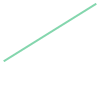

In [21]:
def add_missing(iata_code, notFound):
    if iata_code in notFound:
        notFound[iata_code] += 1;
    else:
        notFound[iata_code] = 1;
        
        
def generate_point(iata_code, notFound={}):
    # find airport
    airport = airports[airports.iata_code==iata_code]
    if(airport.empty):
        add_missing(iata_code, notFound)
        return ''
    
    return Point(airport.longitude_deg, airport.latitude_deg)


# generates a line string between two airport coordinates
def generate_spoke(iata_code_a, iata_code_b, notFound={}):
    # find airports
    airport_a = airports[airports.iata_code==iata_code_a]
    airport_b = airports[airports.iata_code==iata_code_b]
    if(airport_a.empty):
        add_missing(iata_code_a, notFound)
        return ''
    if(airport_b.empty):
        add_missing(iata_code_b, notFound)
        return ''
    
    # airport points
    # coords_a = list(zip(airport_a.longitude_deg, airport_a.latitude_deg))
    # coords_b = list(zip(airport_b.longitude_deg, airport_b.latitude_deg))
    
    # line
    #spoke = list(zip(coords_a, coords_b))
    spoke = LineString([(airport_a.longitude_deg, airport_a.latitude_deg), (airport_b.longitude_deg, airport_b.latitude_deg)])
    
    return spoke
    
generate_spoke('BOS', 'JFK', {})
#generate_point('BOS', {})

In [22]:
# Add airport coordinates
spokes['SPOKE_A_COORDS'] = spokes.apply(lambda row: generate_point(row.SPOKE_A), axis=1)
spokes['SPOKE_B_COORDS'] = spokes.apply(lambda row: generate_point(row.SPOKE_B), axis=1)

/usr/local/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:122: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/var/folders/d5/lgny99w14vn1gwv5q3b69lnc0000gn/T/ipykernel_20157/1910454616.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spokes['SPOKE_A_COORDS'] = spokes.apply(lambda row: generate_point(row.SPOKE_A), axis=1)
/usr/local/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:122: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_list

In [23]:
# Add spoke geometry
spokes['geometry'] = spokes.apply(lambda row: generate_spoke(row.SPOKE_A, row.SPOKE_B), axis=1)

# convert to geopandas GDF
spokes = gpd.GeoDataFrame(spokes)

# reproject
# USA_Contiguous_Albers_Equal_Area_Conic
spokes.set_crs = 102003

spokes

/usr/local/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:122: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/var/folders/d5/lgny99w14vn1gwv5q3b69lnc0000gn/T/ipykernel_20157/3860548898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spokes['geometry'] = spokes.apply(lambda row: generate_spoke(row.SPOKE_A, row.SPOKE_B), axis=1)


,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE,SPOKE_A_COORDS,SPOKE_B_COORDS,geometry
0,ABE,ATL,158.0,10765.0,692.0,POINT (-75.442797 40.651773),POINT (-84.428101 33.6367),"LINESTRING (-75.44280 40.65177, -84.42810 33.6..."
1,ABE,BNA,18.0,2659.0,685.0,POINT (-75.442797 40.651773),POINT (-86.6781997680664 36.1245002746582),"LINESTRING (-75.44280 40.65177, -86.67820 36.1..."
2,ABE,CLT,177.0,10488.0,481.0,POINT (-75.442797 40.651773),POINT (-80.94309997558594 35.2140007019043),"LINESTRING (-75.44280 40.65177, -80.94310 35.2..."
3,ABE,DTW,68.0,3617.0,425.0,POINT (-75.442797 40.651773),POINT (-83.35340118408203 42.212398529052734),"LINESTRING (-75.44280 40.65177, -83.35340 42.2..."
4,ABE,FLL,9.0,1521.0,1041.0,POINT (-75.442797 40.651773),POINT (-80.152702 26.072599),"LINESTRING (-75.44280 40.65177, -80.15270 26.0..."
...,...,...,...,...,...,...,...,...
3840,TUL,VCT,1.0,50.0,510.0,POINT (-95.88809967041016 36.19839859008789),POINT (-96.9185028076172 28.85260009765625),"LINESTRING (-95.88810 36.19840, -96.91850 28.8..."
3841,TUL,VPS,22.0,2857.0,669.0,POINT (-95.88809967041016 36.19839859008789),POINT (-86.525398 30.4832),"LINESTRING (-95.88810 36.19840, -86.52540 30.4..."
3842,TUL,XNA,1.0,96.0,88.0,POINT (-95.88809967041016 36.19839859008789),POINT (-94.306801 36.281898),"LINESTRING (-95.88810 36.19840, -94.30680 36.2..."
3843,TYS,VPS,20.0,2623.0,395.0,POINT (-83.994003 35.811001),POINT (-86.525398 30.4832),"LINESTRING (-83.99400 35.81100, -86.52540 30.4..."


# Find spokes replaceable with 1 additional layover

In [24]:
from haversine import haversine, Unit

def closest_airports(point, airports, threshold):
    # create geopandas geodataframe
    matches = airports.copy()
    matches['Distance'] = matches.apply(lambda row: haversine((row.latitude_deg, row.longitude_deg), (point.y, point.x), unit=Unit.MILES), axis=1)
    matches = matches[(matches.Distance > 0) & (matches.Distance <= threshold)]
    return matches

# Demo: Choose a flight from JFK, then select SPOKE_A (JFK) and find airports within 15 mi distance
test = spokes[(spokes.SPOKE_A=='JFK') & (spokes.SPOKE_B=='LAX')]
closest_airports(test['SPOKE_A_COORDS'].item(), airports, 15)

,type,name,latitude_deg,longitude_deg,iso_country,iso_region,iata_code,geometry,Distance
36135,large_airport,La Guardia Airport,40.777199,-73.872597,US,US-NY,LGA,POINT (-73.87260 40.77720),10.698442


In [25]:
def find_layover(flight, airports, min_range, max_range):
    
    # Skip if flight is longer than 2x max range
    if(flight.DISTANCE > 2*max_range):
        return None
    
    # Skip if flight is shorter than min range
    if(flight.DISTANCE <= min_range):
        return None
    
    # Get all airports within max_range for origin and dest airports
    airports_a = closest_airports(flight['SPOKE_A_COORDS'], airports, max_range)
    airports_b = closest_airports(flight['SPOKE_B_COORDS'], airports, max_range)
    
    # intersect both dataframes
    matches = pd.merge(
        airports_a, 
        airports_b, 
        how='inner', 
        on=['latitude_deg', 'longitude_deg', 'iata_code'],
    )
    
    # exit if no match
    if(len(matches)==0):
        return None
    
    # Calculate total distance
    matches['total_distance'] = matches['Distance_x'] + matches['Distance_y']
    
    # Find longer spoke for this trip, i.e. the min range of the plane needed to fly this trip
    matches['min_range'] = matches.apply(lambda row: math.ceil(max(row.Distance_x, row.Distance_y)), axis='columns')
    
    # Find trip with the shortest spoke, 1 max
    match = matches[matches.min_range == matches.min_range.min()].head(1)
    
    # Select minimum range needed to do this trip
    trip_min_range = max(match.Distance_x.item(), match.Distance_y.item())
    
    # Create a linestring for entire trip
    trip = LineString([
        flight.SPOKE_A_COORDS,
        Point(match.longitude_deg, match.latitude_deg),
        flight.SPOKE_B_COORDS
    ])
    
    # Dict will become columns in flight table
    return {
        'layover': match.iata_code.item(),
        'layover_coords': match.geometry_x.item(),
        'layover_range': math.ceil(trip_min_range),
        'layover_geometry': trip,
        'layover_distance': match.total_distance.item()
    }


test = spokes.head(5)
test[['layover', 'layover_coords', 'layover_range', 'layover_geometry', 'layover_distance']] = test.apply(lambda row: find_layover(row, airports, 200, 800), axis='columns', result_type='expand')
test

/usr/local/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE,SPOKE_A_COORDS,SPOKE_B_COORDS,geometry,layover,layover_coords,layover_range,layover_geometry,layover_distance
0,ABE,ATL,158.0,10765.0,692.0,POINT (-75.442797 40.651773),POINT (-84.428101 33.6367),"LINESTRING (-75.44280 40.65177, -84.42810 33.6...",ROA,POINT (-79.975403 37.3255),358,"LINESTRING (-75.442797 40.651773, -79.975403 3...",691.970141
1,ABE,BNA,18.0,2659.0,685.0,POINT (-75.442797 40.651773),POINT (-86.6781997680664 36.1245002746582),"LINESTRING (-75.44280 40.65177, -86.67820 36.1...",BKW,POINT (-81.1241989136 37.7873001099),363,"LINESTRING (-75.442797 40.651773, -81.12419891...",690.123941
2,ABE,CLT,177.0,10488.0,481.0,POINT (-75.442797 40.651773),POINT (-80.94309997558594 35.2140007019043),"LINESTRING (-75.44280 40.65177, -80.94310 35.2...",CHO,POINT (-78.4529037475586 38.13859939575195),245,"LINESTRING (-75.442797 40.651773, -78.45290374...",481.246098
3,ABE,DTW,68.0,3617.0,425.0,POINT (-75.442797 40.651773),POINT (-83.35340118408203 42.212398529052734),"LINESTRING (-75.44280 40.65177, -83.35340 42.2...",BUF,POINT (-78.73220062 42.94049835),241,"LINESTRING (-75.442797 40.651773, -78.73220062...",472.141072
4,ABE,FLL,9.0,1521.0,1041.0,POINT (-75.442797 40.651773),POINT (-80.152702 26.072599),"LINESTRING (-75.44280 40.65177, -80.15270 26.0...",MYR,POINT (-78.9282989502 33.6796989441),531,"LINESTRING (-75.442797 40.651773, -78.92829895...",1049.100989


### Find layovers and min range to fly them

In [26]:
spokes_layovers = spokes.copy()

spokes_layovers[['layover', 'layover_coords', 'layover_range', 'layover_geometry', 'layover_distance']] = spokes_layovers.apply(lambda row: 
    find_layover(row, airports, 100, 2000),
    axis='columns',
    result_type='expand'
)

spokes_layovers

,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE,SPOKE_A_COORDS,SPOKE_B_COORDS,geometry,layover,layover_coords,layover_range,layover_geometry,layover_distance
0,ABE,ATL,158.0,10765.0,692.0,POINT (-75.442797 40.651773),POINT (-84.428101 33.6367),"LINESTRING (-75.44280 40.65177, -84.42810 33.6...",ROA,POINT (-79.975403 37.3255),358.0,"LINESTRING (-75.442797 40.651773, -79.975403 3...",691.970141
1,ABE,BNA,18.0,2659.0,685.0,POINT (-75.442797 40.651773),POINT (-86.6781997680664 36.1245002746582),"LINESTRING (-75.44280 40.65177, -86.67820 36.1...",BKW,POINT (-81.1241989136 37.7873001099),363.0,"LINESTRING (-75.442797 40.651773, -81.12419891...",690.123941
2,ABE,CLT,177.0,10488.0,481.0,POINT (-75.442797 40.651773),POINT (-80.94309997558594 35.2140007019043),"LINESTRING (-75.44280 40.65177, -80.94310 35.2...",CHO,POINT (-78.4529037475586 38.13859939575195),245.0,"LINESTRING (-75.442797 40.651773, -78.45290374...",481.246098
3,ABE,DTW,68.0,3617.0,425.0,POINT (-75.442797 40.651773),POINT (-83.35340118408203 42.212398529052734),"LINESTRING (-75.44280 40.65177, -83.35340 42.2...",BUF,POINT (-78.73220062 42.94049835),241.0,"LINESTRING (-75.442797 40.651773, -78.73220062...",472.141072
4,ABE,FLL,9.0,1521.0,1041.0,POINT (-75.442797 40.651773),POINT (-80.152702 26.072599),"LINESTRING (-75.44280 40.65177, -80.15270 26.0...",MYR,POINT (-78.9282989502 33.6796989441),531.0,"LINESTRING (-75.442797 40.651773, -78.92829895...",1049.100989
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840,TUL,VCT,1.0,50.0,510.0,POINT (-95.88809967041016 36.19839859008789),POINT (-96.9185028076172 28.85260009765625),"LINESTRING (-95.88810 36.19840, -96.91850 28.8...",TYR,POINT (-95.40239715576172 32.35409927368164),268.0,LINESTRING (-95.88809967041016 36.198398590087...,525.233059
3841,TUL,VPS,22.0,2857.0,669.0,POINT (-95.88809967041016 36.19839859008789),POINT (-86.525398 30.4832),"LINESTRING (-95.88810 36.19840, -86.52540 30.4...",GLH,POINT (-90.98560333251952 33.4828987121582),336.0,LINESTRING (-95.88809967041016 36.198398590087...,668.847758
3842,TUL,XNA,1.0,96.0,88.0,POINT (-95.88809967041016 36.19839859008789),POINT (-94.306801 36.281898),"LINESTRING (-95.88810 36.19840, -94.30680 36.2...",None,None,NaN,None,NaN
3843,TYS,VPS,20.0,2623.0,395.0,POINT (-83.994003 35.811001),POINT (-86.525398 30.4832),"LINESTRING (-83.99400 35.81100, -86.52540 30.4...",BHM,POINT (-86.753502 33.562901),221.0,"LINESTRING (-83.994003 35.811001, -86.753502 3...",433.879927


<AxesSubplot:ylabel='Frequency'>

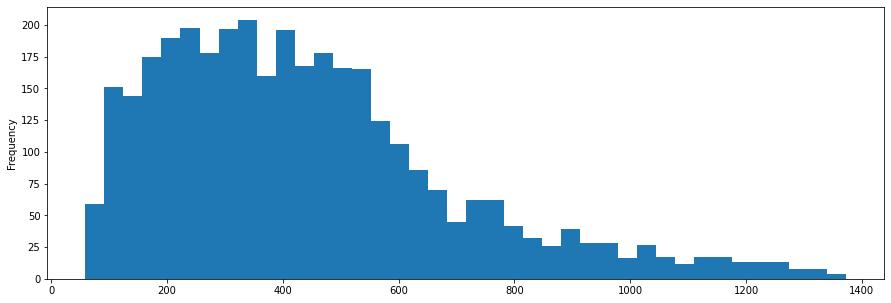

In [27]:
spokes_layovers.layover_range.plot.hist(bins=40, figsize=(15,5))

In [28]:
# quantiles of range needed to replace % of spokes
spokes_layovers.layover_range.quantile([.25, .5, .75, .8, .9, 1])

0.25     246.0
0.50     397.0
0.75     561.0
0.80     616.0
0.90     790.0
1.00    1373.0
Name: layover_range, dtype: float64

In [29]:
# Quantiles of spoke distances
spokes_layovers.DISTANCE.quantile([.25, .5, .75, .8, .9, 1])

0.25     426.0
0.50     734.0
0.75    1072.5
0.80    1175.0
0.90    1520.2
1.00    2724.0
Name: DISTANCE, dtype: float64

<AxesSubplot:>

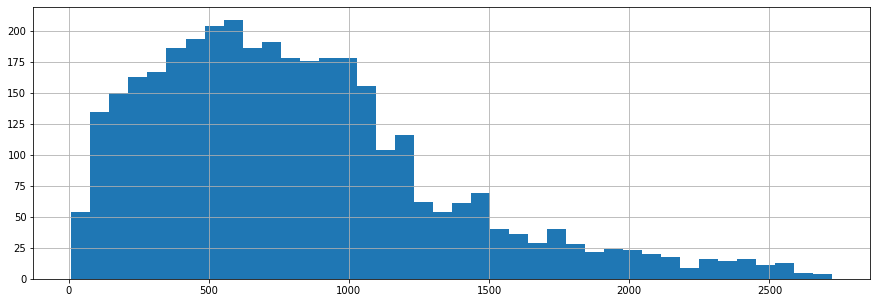

In [30]:
spokes_layovers.DISTANCE.hist(bins=40, figsize=(15,5))

In [31]:
spokes_layovers.DEPARTURES_PERFORMED.sum()

542804.0

# Create output file

In [34]:
data = spokes_layovers.copy()

# version 1, layovers only: use layover linestrings as geometry
# data_filename = 'layovers_100-2000'
# data = data.drop(columns=['geometry', 'SPOKE_A_COORDS', 'SPOKE_B_COORDS', 'layover_coords'])
# data = data.rename(columns={"layover_geometry": "geometry"})

# version 2, all spokes
data_filename = 'spokes'
data = data.drop(columns=['layover_geometry', 'SPOKE_A_COORDS', 'SPOKE_B_COORDS', 'layover_coords'])

# Create output table
data = gpd.GeoDataFrame(data, geometry='geometry')

data

,SPOKE_A,SPOKE_B,DEPARTURES_PERFORMED,PASSENGERS,DISTANCE,layover,layover_range,geometry,layover_distance
0,ABE,ATL,158.0,10765.0,692.0,ROA,358.0,"LINESTRING (-75.44280 40.65177, -79.97540 37.3...",691.970141
1,ABE,BNA,18.0,2659.0,685.0,BKW,363.0,"LINESTRING (-75.44280 40.65177, -81.12420 37.7...",690.123941
2,ABE,CLT,177.0,10488.0,481.0,CHO,245.0,"LINESTRING (-75.44280 40.65177, -78.45290 38.1...",481.246098
3,ABE,DTW,68.0,3617.0,425.0,BUF,241.0,"LINESTRING (-75.44280 40.65177, -78.73220 42.9...",472.141072
4,ABE,FLL,9.0,1521.0,1041.0,MYR,531.0,"LINESTRING (-75.44280 40.65177, -78.92830 33.6...",1049.100989
...,...,...,...,...,...,...,...,...,...
3840,TUL,VCT,1.0,50.0,510.0,TYR,268.0,"LINESTRING (-95.88810 36.19840, -95.40240 32.3...",525.233059
3841,TUL,VPS,22.0,2857.0,669.0,GLH,336.0,"LINESTRING (-95.88810 36.19840, -90.98560 33.4...",668.847758
3842,TUL,XNA,1.0,96.0,88.0,None,NaN,None,NaN
3843,TYS,VPS,20.0,2623.0,395.0,BHM,221.0,"LINESTRING (-83.99400 35.81100, -86.75350 33.5...",433.879927


In [35]:
# Save file
data.to_file(folder + data_filename + '.geojson', driver="GeoJSON")

## Export airports.geojson

In [36]:
ap_out = airports.copy()
ap_out = ap_out.drop(columns=['type', 'iso_country', 'latitude_deg', 'longitude_deg'])
ap_out.to_file(folder + 'airports.geojson', driver='GeoJSON')